In [1]:
import os
import random

import anndata
import numpy as np
import pandas as pd
import scanpy as sc

import simulate
import config

import squidpy as sq

/opt/conda/envs/attn/lib/python3.9/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/opt/conda/envs/attn/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
adata = sc.read_h5ad('./pbmc_ad.h5ad')


In [ ]:
adata = sc.read_h5ad('./pbmc_ad.h5ad')
adata = simulate.generate_synthetic_dataset(adata)
adata = simulate._subcluster(
    adata, n_subcluster_per_cluster=2, n_genes_for_subclustering=200,
    random_state=500#45
)

<Axes: ylabel='Count'>

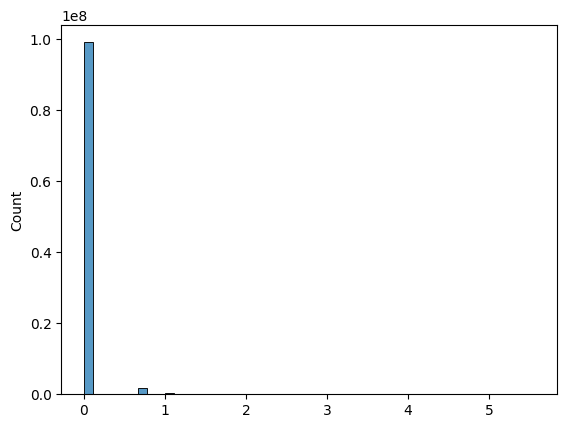

In [4]:
idx = np.arange(adata.shape[0])
np.random.shuffle(idx)
idx = idx[:5000] 

adata_sub = adata[idx, :]
genes = np.log(adata_sub.X.toarray().flatten()+1)
# genes = genes[genes < 10]
# idx = np.arange(len(genes))
# np.random.shuffle(idx)
# idx = idx[:100000]

import seaborn as sns
sns.histplot(genes.flatten(), bins=50)

In [5]:
np.sum(adata.X != 0)/(adata.X.shape[0] * adata.X.shape[1])

0.02669534306872082

In [12]:
np.sum(adata_sub.X != 0)

2747347

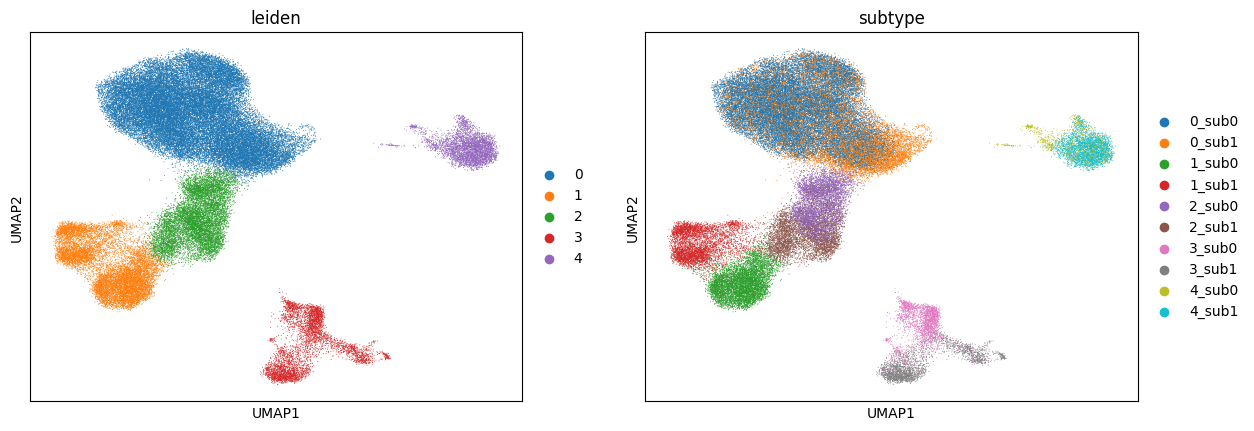

In [4]:
adata.obs['avg_expr_subclustering_1'] = adata[:, adata.var['is_gene_for_subclustering_1']].X.mean(axis=1)
adata.obs['avg_expr_subclustering_3'] = adata[:, adata.var['is_gene_for_subclustering_3']].X.mean(axis=1)

sc.pl.umap(adata, color=['leiden', 'subtype'])

# sc.pl.umap(adata, color='avg_expr_subclustering_1', title='UMAP for Subcluster 1')
# sc.pl.umap(adata, color='avg_expr_subclustering_3', title='UMAP for Subcluster 3')

In [5]:
adata.shape

(67931, 500)

In [6]:
interaction_df = config.get_3ct_interaction()
interaction_df["radius_of_effect"] = interaction_df["radius_of_effect"].astype(
    float
)

use_confounder=False
confounder_noise=False
confounder_prob=3e-1
adata_ = simulate.generate_coordinates(adata, interaction_df,
                                                use_confounder=use_confounder,
                                                confounder_noise=confounder_noise,
                                                confounder_prob=confounder_prob,
                                                num_cells=20000
                                                )
subtype_counts = adata_.obs['subtype'].value_counts()
print(subtype_counts)

subtype
1_sub0    6003
2_sub0    5986
4_sub0    5042
1_sub1    2194
2_sub1     775
Name: count, dtype: int64


/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make t

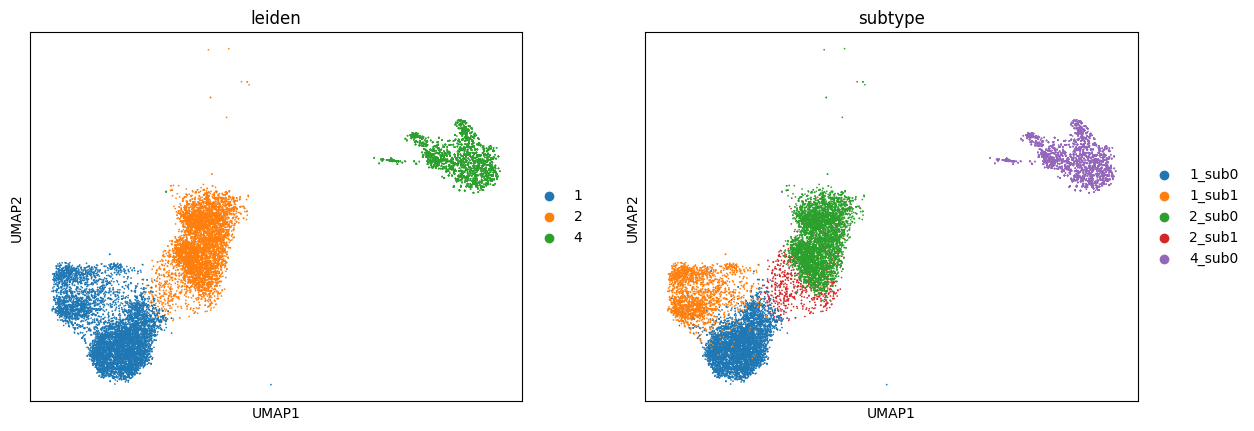

In [7]:
sc.pl.umap(adata_, color=['leiden', 'subtype'])


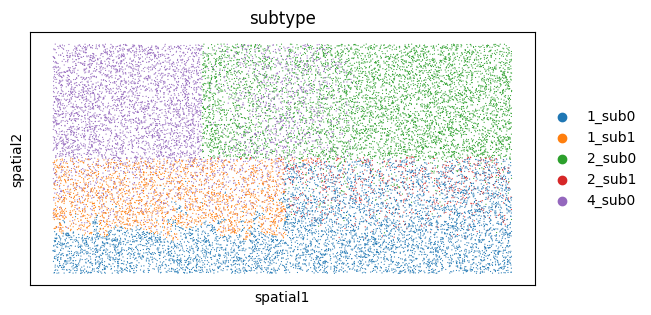

In [8]:
sq.pl.spatial_scatter(adata_, color='subtype', img=False, size=5)

In [ ]:
sq.pl.spatial_scatter(adata_[adata_.obs.subtype=='0_sub0'], color='subtype', img=False, size=5)

In [10]:
sc.write('../data/synthetic_raw.h5ad', adata)
sc.write('../data/synthetic_interaction.h5ad', adata_)
interaction_df.to_csv('../data/interaction.csv', index=False)